<a href="https://colab.research.google.com/github/Georgeandro/ML_Notebooks/blob/main/DGM_LSMC_american_option_pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 AMERICAN OPTION PRICING NOTEBOOK
-- Using Longstaff–Schwartz & DGM --

##  American Put Pricing: Notebook Parameters and Characteristics

This notebook implements pricing and analysis of an **American Put Option** using:

- **1. Longstaff–Schwartz Monte Carlo (LSMC)**
- **2. Deep Galerkin Method (DGM)** with free-boundary PDE formulation

###  Model and Option Parameters

| Variable        | Description                                      | Value (Default)  |
|-----------------|--------------------------------------------------|------------------|
| `K`             | Strike price                                     | `1.0`            |
| `r`             | Risk-free interest rate                          | `0.01` (1%)      |
| `sigma`         | Volatility of underlying asset                   | `0.2` (20%)      |
| `T`             | Total maturity time (in years)                   | `1.0`            |
| `S0` / `S_initial` | Initial stock price                           | Typically `1.0`  |
| `T_eff`         | Effective maturity (for LSMC), `T_eff = T - t`   | varies per slice |

###  Deep Galerkin Method (DGM) Settings

| Variable        | Description                         | Value          |
|-----------------|-------------------------------------|----------------|
| `n_epochs`      | Number of training epochs           | `2000`         |
| `n_samples`     | Samples per epoch (interior/bound)  | `512`          |
| `lr`            | Learning rate for optimizer         | `1e-3`         |
| `hidden_size`   | Hidden layer width                  | `50`           |
| `n_layers`      | Depth of DGM architecture           | `3`            |

###  Monte Carlo (LSMC) Settings

| Variable        | Description                             | Value          |
|-----------------|-----------------------------------------|----------------|
| `N_paths`       | Number of Monte Carlo paths             | `8000 – 20000` |
| `N_steps`       | Time discretization steps               | `50`           |
| `poly_deg`      | Polynomial degree for regression        | `1 or 2`       |
| `min_itm_points`| Min. ITM paths to apply regression      | `3`            |
| `h`             | Step size for finite-diff Greeks        | `0.01`         |

---

###  Notes on Greek Plots

- When plotting **Delta** or **Gamma**:
  - Each point on the graph corresponds to a **different spot price** \( S \).
  - The x-axis is either `Delta` or `Gamma` value (computed at a given \( S \)).
  - The y-axis is the **option value** corresponding to that \( S \).

This lets you visualise how:
- The option value behaves **as a function of its sensitivity**
- The **local curvature** (Gamma) evolves over time and price

---

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Attempt to use a T4 or any CUDA GPU if available:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [ ]:
def simulate_GBM_paths(S0, r, sigma, T, N_paths, N_steps, seed=1234):
    """
    Simulate geometric Brownian motion paths for underlying asset price.
    Each path has (N_steps+1) time points, from t=0 to t=T inclusive.
    """
    dt = T / N_steps
    torch.manual_seed(seed)
    dW = torch.randn(N_paths, N_steps, device='cpu')  # We'll do random draws on CPU
    S = torch.zeros(N_paths, N_steps+1, device='cpu')
    S[:, 0] = S0

    for t in range(N_steps):
        S[:, t+1] = S[:, t] * torch.exp((r - 0.5*sigma**2)*dt
                                       + sigma*math.sqrt(dt)*dW[:, t])
    return S


def american_put_LSMC(S0=1.0, K=1.0, r=0.01, sigma=0.2,
                      T=1.0, N_paths=10000, N_steps=50,
                      poly_deg=2,       # polynomial degree
                      min_itm_points=3, # skip polyfit if fewer ITM
                      seed=1234):
    """
    Price an American put via Longstaff–Schwartz (NumPy polyfit).
    Payoff = max(K - S, 0).

    - We compute everything on the ITM subset, and then reinsert into full arrays.
    - If # of ITM points < min_itm_points => fallback to immediate exercise
    - If np.polyfit fails => fallback to immediate exercise
    - By default uses deg=2 polynomial, can be set to deg=1 for stability
    """

    dt = T / N_steps
    torch.manual_seed(seed)
    dW = torch.randn(N_paths, N_steps, device='cpu')
    S = torch.zeros(N_paths, N_steps+1, device='cpu')
    S[:, 0] = S0

    for t in range(N_steps):
        S[:, t+1] = S[:, t] * torch.exp((r - 0.5*sigma**2)*dt
                                          + sigma*math.sqrt(dt)*dW[:, t])

    discount = math.exp(-r*dt)
    payoff_maturity = torch.clamp(K - S[:, -1], min=0.0)
    cashflow = payoff_maturity.clone()

    for step in range(N_steps - 1, 0, -1):
        in_the_money = (K - S[:, step] > 0)

        if not torch.any(in_the_money):
            # discount entire CF if no ITM paths
            cashflow *= discount
            continue

        # discount existing CF
        cashflow *= discount

        # Subset: shape ~ (# of ITM), e.g. 7996
        X = S[in_the_money, step]
        Y = cashflow[in_the_money]

        X_np = X.detach().cpu().numpy()
        Y_np = Y.detach().cpu().numpy()

        if len(X_np) < min_itm_points:
            # fallback to immediate exercise
            sub_exercise_val = K - X
            # place back
            temp_cash = cashflow[in_the_money]
            temp_cash[:] = sub_exercise_val
            cashflow[in_the_money] = temp_cash

        else:
            try:
                # polynomial regression
                coefs = np.polyfit(X_np, Y_np, deg=poly_deg)
                cont_np = np.polyval(coefs, X_np)
                continuation_vals = torch.from_numpy(cont_np).to(X.device)

                # immediate exercise on the subset
                sub_exercise_val = K - X

                # decide which sub-paths to exercise
                sub_mask = (sub_exercise_val > continuation_vals)

                # sub update
                temp_cash = cashflow[in_the_money]  # shape ~ (# of ITM)
                temp_cash[sub_mask] = sub_exercise_val[sub_mask]
                cashflow[in_the_money] = temp_cash

            except np.linalg.LinAlgError:
                # fallback if polyfit fails
                sub_exercise_val = K - X
                temp_cash = cashflow[in_the_money]
                temp_cash[:] = sub_exercise_val
                cashflow[in_the_money] = temp_cash

    return cashflow.mean().item()

def american_put_LSMC_partial_time(S0, K, r, sigma, T_eff,
                                   N_paths=10000, N_steps=50,
                                   poly_deg=2, min_itm_points=3, seed=1234):
    """
    Re-price an American put from scratch with leftover maturity T_eff.
    Interpreted as if we start now at (t=0) with that T_eff.
    """
    return american_put_LSMC(S0, K, r, sigma,
                             T_eff, N_paths, N_steps,
                             poly_deg=poly_deg, min_itm_points=min_itm_points,
                             seed=seed)


def lsmc_greeks_finite_diff(S0, K, r, sigma, T_eff,
                            h=0.01, N_paths=10000, N_steps=50,
                            poly_deg=2, min_itm_points=3, seed=1234):
    """
    Finite-difference approach for Delta & Gamma at leftover T_eff.
     - Delta ~ (V(S0+h)-V(S0-h)) / (2*h)
     - Gamma ~ (V(S0+h)-2V(S0)+V(S0-h)) / (h^2)
    We'll pass poly_deg, min_itm_points to american_put_LSMC.
    """
    val_center = american_put_LSMC_partial_time(
        S0, K, r, sigma, T_eff, N_paths, N_steps,
        poly_deg=poly_deg, min_itm_points=min_itm_points, seed=seed
    )
    val_plus = american_put_LSMC_partial_time(
        S0 + h, K, r, sigma, T_eff, N_paths, N_steps,
        poly_deg=poly_deg, min_itm_points=min_itm_points, seed=seed
    )
    val_minus = american_put_LSMC_partial_time(
        S0 - h, K, r, sigma, T_eff, N_paths, N_steps,
        poly_deg=poly_deg, min_itm_points=min_itm_points, seed=seed
    )

    delta = (val_plus - val_minus)/(2*h)
    gamma = (val_plus - 2*val_center + val_minus)/(h*h)
    return val_center, delta, gamma


In [ ]:
def payoff_put(S, K=1.0):
    return torch.clamp(K - S, min=0.0)

class DGMNet(nn.Module):
    """
    A DGM network (Sirignano & Spiliopoulos) for 1D S + 1D time.
    """
    def __init__(self, hidden_size=50, n_layers=3):
        super().__init__()
        self.input_layer = nn.Linear(2, hidden_size)
        self.z_layers = nn.ModuleList([nn.Linear(hidden_size, hidden_size) for _ in range(n_layers)])
        self.g_layers = nn.ModuleList([nn.Linear(hidden_size, hidden_size) for _ in range(n_layers)])
        self.r_layers = nn.ModuleList([nn.Linear(hidden_size, hidden_size) for _ in range(n_layers)])
        self.h_layers = nn.ModuleList([nn.Linear(hidden_size, hidden_size) for _ in range(n_layers)])
        self.output_layer = nn.Linear(hidden_size, 1)
        self.activation = torch.tanh

    def forward(self, t, s):
        # t, s shape: (batch_size,)
        inp = torch.stack((t, s), dim=1)
        x = self.activation(self.input_layer(inp))

        for z_lin, g_lin, r_lin, h_lin in zip(self.z_layers, self.g_layers,
                                             self.r_layers, self.h_layers):
            z = self.activation(z_lin(x))
            g = self.activation(g_lin(x))
            r_ = self.activation(r_lin(x))
            h = self.activation(h_lin(x * r_))
            x = (1 - g)*h + z*x

        out = self.output_layer(x)
        return out.squeeze(-1)


def PDE_residual(t, S, net, r=0.01, sigma=0.2, K=1.0):
    """
    PDE in continuation region:
      u_t + 0.5*sigma^2*S^2*u_SS + r*S*u_S - r*u = 0
    We'll compute but only impose if net>= payoff in free_boundary_loss.
    """
    t.requires_grad_(True)
    S.requires_grad_(True)
    u = net(t, S)

    grad_u_t = torch.autograd.grad(u, t,
                                   grad_outputs=torch.ones_like(u),
                                   create_graph=True)[0]
    grad_u_S = torch.autograd.grad(u, S,
                                   grad_outputs=torch.ones_like(u),
                                   create_graph=True)[0]
    grad2_u_S2 = torch.autograd.grad(grad_u_S, S,
                                     grad_outputs=torch.ones_like(u),
                                     create_graph=True)[0]

    return grad_u_t + 0.5*sigma**2*S**2*grad2_u_S2 + r*S*grad_u_S - r*u


def free_boundary_loss(net, t_samps, S_samps, r, sigma, K):
    """
    EXACT approach from the paper:
      if net>= payoff => PDE penalty, else => obstacle penalty
    """
    t_samps.requires_grad_(True)
    S_samps.requires_grad_(True)

    u_val = net(t_samps, S_samps)
    payoff_val = payoff_put(S_samps, K)
    pde_val = PDE_residual(t_samps, S_samps, net, r, sigma, K)

    mask = (u_val >= payoff_val)
    # PDE penalty => pde_val^2
    # obstacle => (u_val - payoff_val)^2
    loss_vec = torch.where(mask,
                           pde_val**2,
                           (u_val - payoff_val)**2)
    return loss_vec.mean()


def terminal_condition_loss(net, S, T, K):
    tT = torch.full_like(S, T)
    uT = net(tT, S)
    return (uT - payoff_put(S, K))**2


def boundary_condition_loss(net, t, K):
    S0 = torch.zeros_like(t)
    val0 = net(t, S0)
    bc0 = (val0 - K)**2  # at S=0 => option ~ K

    Smax = 3.0*K
    S_big = torch.full_like(t, Smax)
    val_big = net(t, S_big)
    bc1 = (val_big - 0.0)**2

    return bc0 + bc1


def train_free_boundary_dgm(K=1.0, r=0.01, sigma=0.2, T=1.0,
                            n_epochs=4000, n_samples=1024, lr=1e-3):
    """
    Train a DGM net for American put PDE:
      if net>= payoff => PDE
      else => obstacle
      + boundary & terminal conditions
    """
    net = DGMNet(hidden_size=50, n_layers=3).to(DEVICE)
    optimizer = optim.Adam(net.parameters(), lr=lr)

    losses = []
    for epoch in range(n_epochs):
        optimizer.zero_grad()

        t_in = torch.rand(n_samples, device=DEVICE)*T
        S_in = torch.rand(n_samples, device=DEVICE)*3.0*K
        loss_fb = free_boundary_loss(net, t_in, S_in, r, sigma, K)

        S_term = torch.rand(n_samples, device=DEVICE)*3.0*K
        loss_term = terminal_condition_loss(net, S_term, T, K).mean()

        t_bc = torch.rand(n_samples, device=DEVICE)*T
        loss_bc = boundary_condition_loss(net, t_bc, K).mean()

        total_loss = loss_fb + loss_term + loss_bc
        total_loss.backward()
        optimizer.step()

        losses.append(total_loss.item())
        if (epoch+1) % 500 == 0:
            print(f"Epoch {epoch+1}, Loss={total_loss.item():.6f}")

    return net, losses


def compute_greeks_dgm(net, t_vals, s_vals, device):
    """
    Return { "price":..., "delta":..., "gamma":... }
    for each (t_vals[i], s_vals[i]).
    """
    net.eval()  # doesn't disable gradient
    t_ten = torch.tensor(t_vals, device=device, dtype=torch.float32, requires_grad=True)
    s_ten = torch.tensor(s_vals, device=device, dtype=torch.float32, requires_grad=True)

    u = net(t_ten, s_ten)
    # Delta
    delta = torch.autograd.grad(u, s_ten,
                                grad_outputs=torch.ones_like(u),
                                create_graph=True)[0]
    # Gamma
    gamma = torch.autograd.grad(delta, s_ten,
                                grad_outputs=torch.ones_like(delta),
                                create_graph=True)[0]

    return {
        "price": u.detach().cpu().numpy(),
        "delta": delta.detach().cpu().numpy(),
        "gamma": gamma.detach().cpu().numpy()
    }


Epoch 500, Loss=0.000327
Epoch 1000, Loss=0.000192
Epoch 1500, Loss=0.000081
Epoch 2000, Loss=0.000033
DGM training complete.


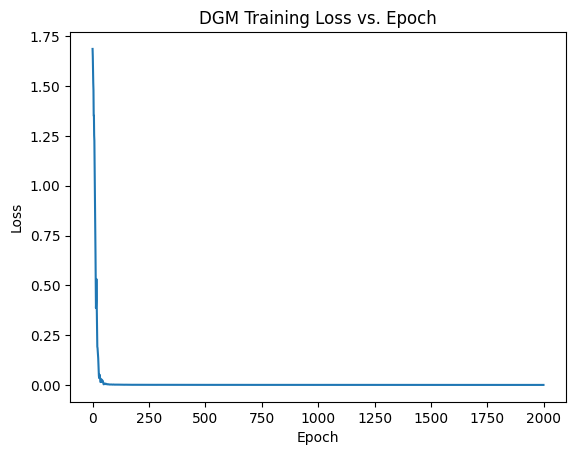

In [ ]:
model, losses = train_free_boundary_dgm(
    K=1.0, r=0.01, sigma=0.2, T=1.0,
    n_epochs=2000,  # or more for better accuracy
    n_samples=512,
    lr=1e-3
)
print("DGM training complete.")

plt.figure()
plt.plot(losses)
plt.title("DGM Training Loss vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
time_slices = [0.0, 0.25, 0.5, 0.75, 1.0]
K = 1.0
r = 0.01
sigma = 0.2
T = 1.0

# We'll pick a small set of S points
S_points = np.linspace(0, 2, 5)
h = 0.01

# We'll do deg=1 for stability, skip polyfit if fewer than 3 ITM points
lsmc_poly_deg = 1
lsmc_min_points = 3

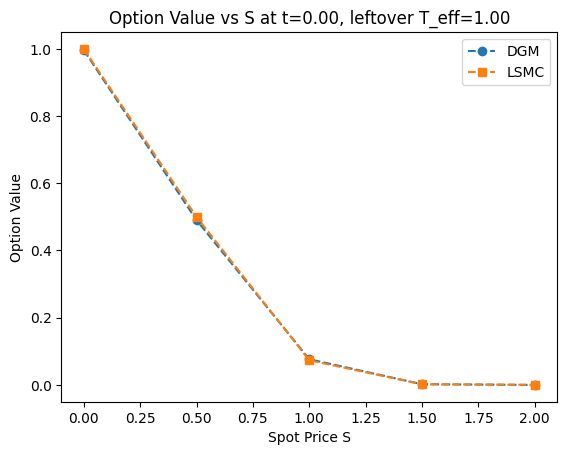

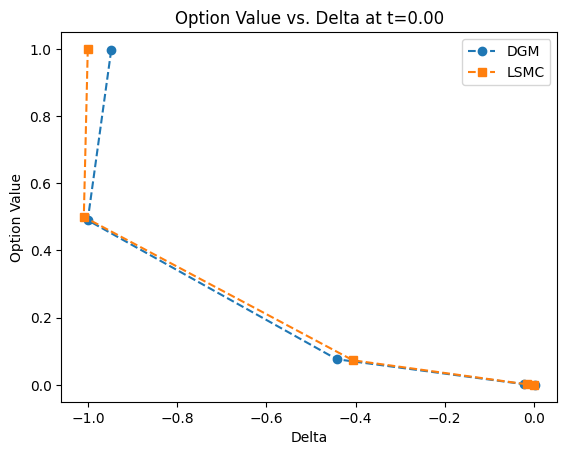

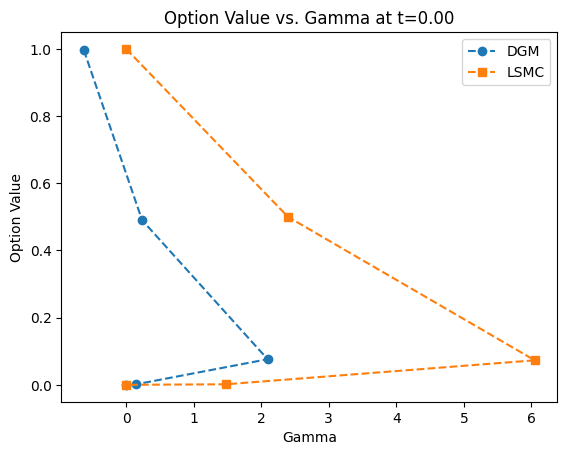

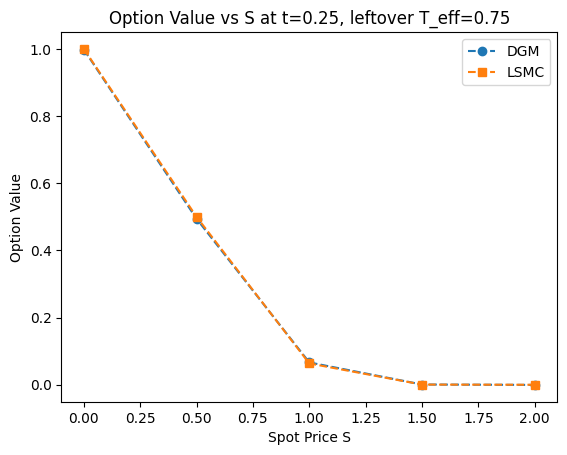

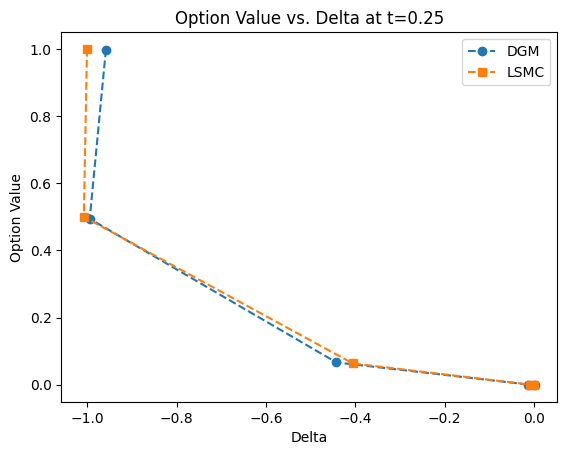

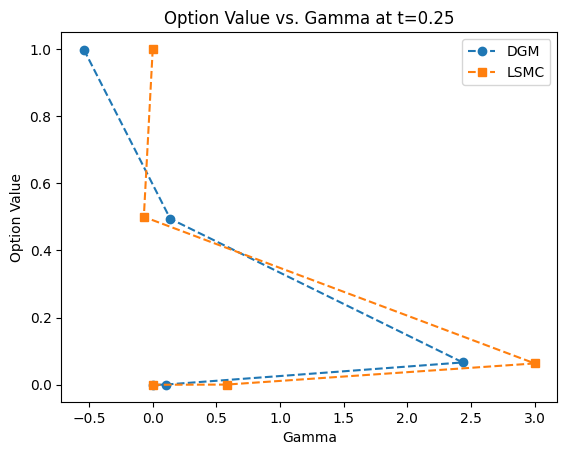

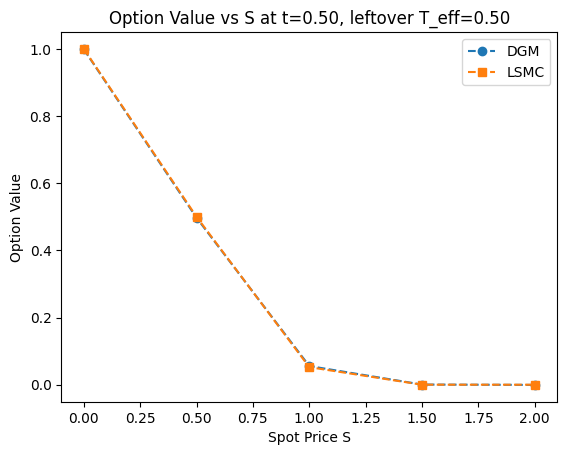

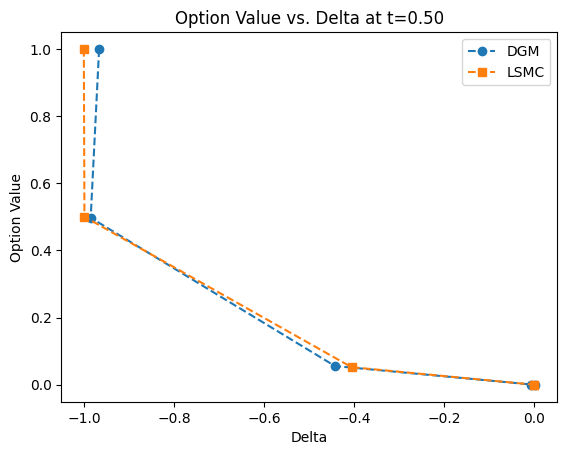

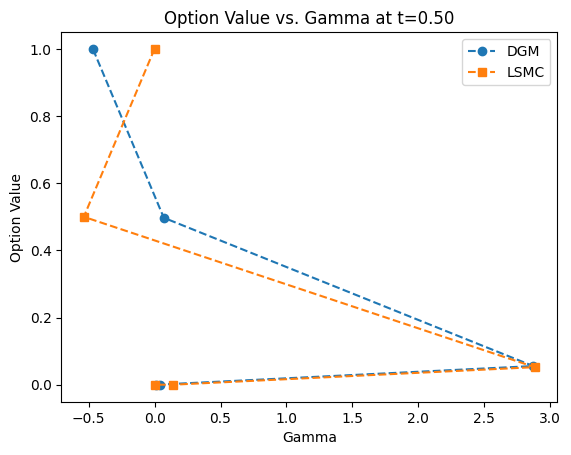

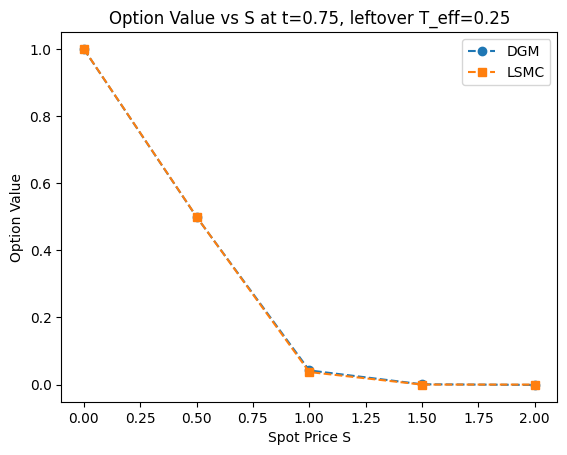

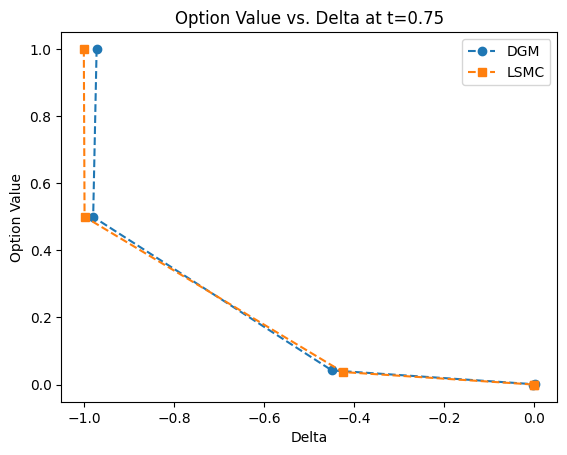

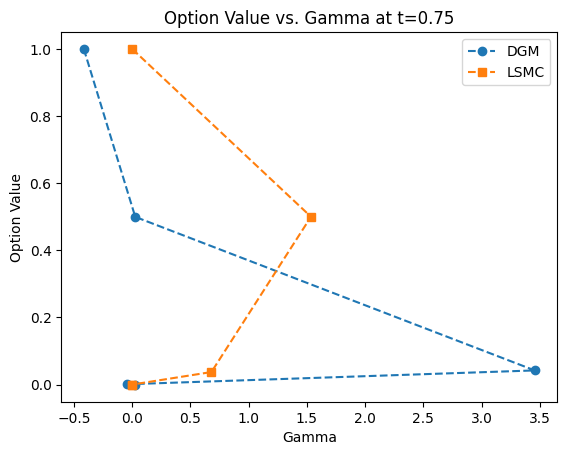

<ipython-input-37-105e227857e7>:81: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(X_np, Y_np, deg=poly_deg)
<ipython-input-37-105e227857e7>:81: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(X_np, Y_np, deg=poly_deg)
<ipython-input-37-105e227857e7>:81: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(X_np, Y_np, deg=poly_deg)
<ipython-input-37-105e227857e7>:81: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(X_np, Y_np, deg=poly_deg)
<ipython-input-37-105e227857e7>:81: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(X_np, Y_np, deg=poly_deg)
<ipython-input-37-105e227857e7>:81: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(X_np, Y_np, deg=poly_deg)
<ipython-input-37-105e227857e7>:81: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(X_np, Y_np, deg=poly_deg)
<ipython-input-37-105e227857e7>:81: RankWarning: Polyfit may be poorly conditioned
  coefs

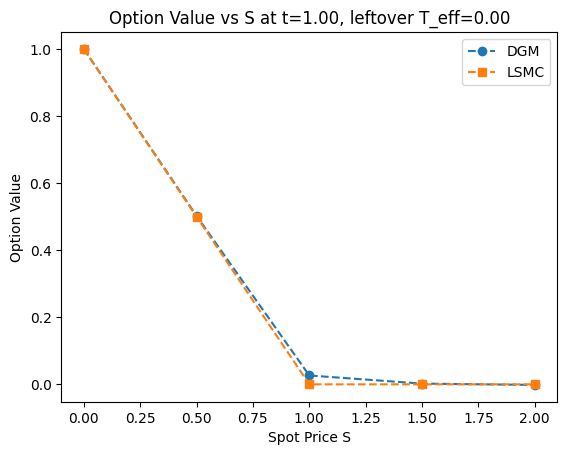

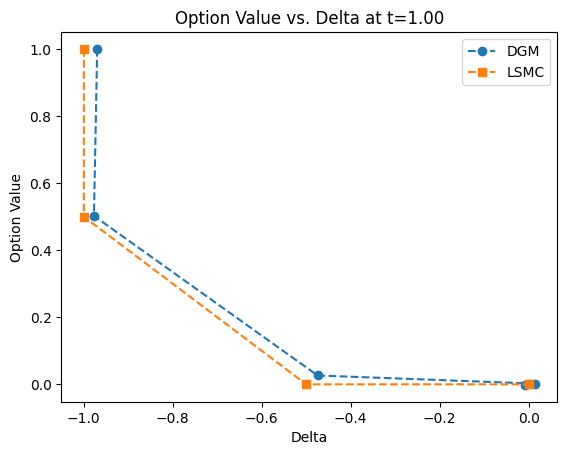

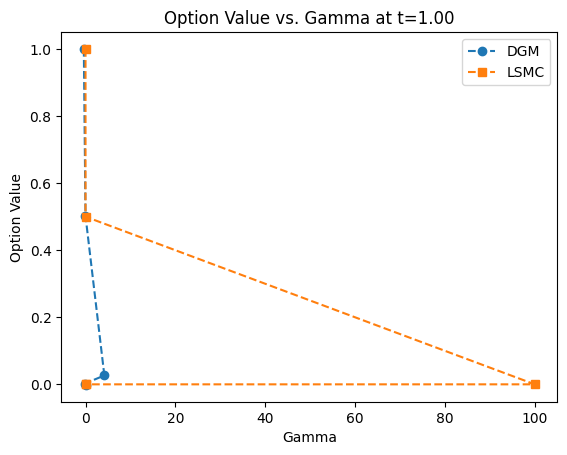

In [ ]:
for t_ in time_slices:
    T_eff = T - t_
    dgm_vals, dgm_deltas, dgm_gammas = [], [], []
    mc_vals, mc_deltas, mc_gammas = [], [], []

    for s_ in S_points:
        # PDE net
        greeks_res = compute_greeks_dgm(model, [t_], [s_], DEVICE)
        dgm_vals.append(greeks_res["price"][0])
        dgm_deltas.append(greeks_res["delta"][0])
        dgm_gammas.append(greeks_res["gamma"][0])

        # LSMC Price + Greeks
        val_s = american_put_LSMC(
            S0=s_, K=K, r=r, sigma=sigma,
            T=T_eff, N_paths=8000, N_steps=50,
            poly_deg=lsmc_poly_deg,
            min_itm_points=lsmc_min_points
        )

        val_center, delta_mc, gamma_mc = lsmc_greeks_finite_diff(
            s_, K, r, sigma, T_eff,
            h=h, N_paths=4000, N_steps=50,
            poly_deg=lsmc_poly_deg,
            min_itm_points=lsmc_min_points
        )

        mc_vals.append(val_s)
        mc_deltas.append(delta_mc)
        mc_gammas.append(gamma_mc)

    dgm_vals  = np.array(dgm_vals)
    dgm_deltas= np.array(dgm_deltas)
    dgm_gammas= np.array(dgm_gammas)
    mc_vals   = np.array(mc_vals)
    mc_deltas = np.array(mc_deltas)
    mc_gammas = np.array(mc_gammas)

    # 1) Value vs. S
    plt.figure()
    plt.plot(S_points, dgm_vals, "o--", label="DGM")
    plt.plot(S_points, mc_vals,  "s--", label="LSMC")
    plt.title(f"Option Value vs S at t={t_:.2f}, leftover T_eff={T_eff:.2f}")
    plt.xlabel("Spot Price S")
    plt.ylabel("Option Value")
    plt.legend()
    plt.show()

    # 2) Value vs. Delta
    plt.figure()
    plt.plot(dgm_deltas, dgm_vals, "o--", label="DGM")
    plt.plot(mc_deltas, mc_vals,  "s--", label="LSMC")
    plt.title(f"Option Value vs. Delta at t={t_:.2f}")
    plt.xlabel("Delta")
    plt.ylabel("Option Value")
    plt.legend()
    plt.show()

    # 3) Value vs. Gamma
    plt.figure()
    plt.plot(dgm_gammas, dgm_vals, "o--", label="DGM")
    plt.plot(mc_gammas, mc_vals,  "s--", label="LSMC")
    plt.title(f"Option Value vs. Gamma at t={t_:.2f}")
    plt.xlabel("Gamma")
    plt.ylabel("Option Value")
    plt.legend()
    plt.show()